# Verification: BNGL model vs Paper Eq. (1)

Verify that the BNGL parameter scan reproduces Fig. 8 (top panel,
$\gamma = 0.0231\;\text{min}^{-1}$) in Dreisigmeyer et al. (2008).

**Method:** Implement the paper's Eq. (1) independently in Python/SciPy,
solve to steady state for a range of $l^*$ values, and compare against
the BioNetGen `.scan` output.

In [1]:
import subprocess, os
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath("__file__")))

## 1. Run BioNetGen model

In [2]:
BNGL_FILE = "lac_operon_lactose_induction_dreisigmeyer2008.bngl"
SCAN_FILE = "lac_operon_lactose_induction_dreisigmeyer2008_scan.scan"

result = subprocess.run(
    ["bionetgen", "run", "-i", BNGL_FILE],
    capture_output=True, text=True
)
assert result.returncode == 0, f"BNG failed:\n{result.stderr}"
print("BioNetGen finished successfully.")

BioNetGen finished successfully.


## 2. Independent implementation of paper Eq. (1)

In [3]:
def paper_eq1(t, y, p):
    """Dreisigmeyer et al. (2008) Eq. (1), verbatim from the paper.

    Variables: l (internal lactose), a (allolactose), z (beta-gal), all in uM.
    """
    l, a, z = y
    l_ext = p["l_ext"]
    gamma = p["gamma"]
    rho   = p["rho"]

    # Shared competitive-inhibition denominator for metabolism
    denom = 1 + a / p["K_m_a"] + l / p["K_m_l"]

    # Eq. (1a)
    dl = (p["alpha"] * z * (l_ext - p["phi"] * rho * l)
              / (p["K_i"] + l_ext + rho * l)
          - p["beta"] * z * (l / p["K_m_l"]) / denom
          - gamma * l)

    # Eq. (1b)
    da = (p["nu"] * p["beta"] * z * (l / p["K_m_l"]) / denom
          - p["delta"] * z * (a / p["K_m_a"]) / denom
          - gamma * a)

    # Eq. (1c)
    dz = (p["c"] * gamma
          + p["eps"] * gamma * a**p["n"] / (p["K_z"]**p["n"] + a**p["n"])
          - gamma * z)

    return [dl, da, dz]


# Table 1 nominal values, converted to uM
PARAMS = dict(
    alpha = 600.0,      # /min
    phi   = 0.5,        # dimensionless
    rho   = 0.1,        # dimensionless
    K_i   = 500.0,      # uM  (5e5 nM)
    beta  = 2.85e4,     # /min
    nu    = 0.468,       # dimensionless
    K_m_l = 2530.0,     # uM  (2.53 mM)
    delta = 2.30e4,     # /min
    K_m_a = 1200.0,     # uM  (1.2 mM)
    gamma = 0.0231,     # /min
    c     = 0.0343,     # uM  (34.3 nM)
    eps   = 34.285,     # uM  (34286 nM)
    K_z   = 105.0,      # uM  (1.05e5 nM)
    n     = 2.0,        # dimensionless
    l_ext = 0.0,        # placeholder
)

## 3. Solve to steady state for each $l^*$

In [4]:
# Load BNG scan output
bng_data = np.loadtxt(SCAN_FILE, comments="#")
bng_lx = bng_data[:, 0]   # l_ext values
bng_L  = bng_data[:, 1]   # Obs_Tot_L at steady state
bng_A  = bng_data[:, 2]   # Obs_Tot_A at steady state
bng_Z  = bng_data[:, 3]   # Obs_Tot_Z at steady state

# Solve paper Eq. (1) at the same l_ext values
y0 = [0.0, 0.0, PARAMS["c"]]   # uninduced IC
paper_L = np.empty_like(bng_lx)
paper_A = np.empty_like(bng_lx)
paper_Z = np.empty_like(bng_lx)

for i, lx in enumerate(bng_lx):
    p = {**PARAMS, "l_ext": lx}
    sol = solve_ivp(paper_eq1, [0, 2000], y0, args=(p,),
                    method="BDF", rtol=1e-10, atol=1e-12)
    paper_L[i], paper_A[i], paper_Z[i] = sol.y[:, -1]

print(f"Solved {len(bng_lx)} steady states.")

Solved 100 steady states.


## 4. Comparison table

In [5]:
check_lx = [0.01, 1, 10, 100, 500, 1000, 5000, 1e4, 1e5, 1e6]

print(f"{'l_ext (uM)':>12}  {'Paper Z':>10}  {'BNG Z':>10}  {'rel err':>8}")
print("-" * 48)
for lx in check_lx:
    i = np.argmin(np.abs(bng_lx - lx))
    err = abs(bng_Z[i] - paper_Z[i]) / max(paper_Z[i], 1e-15) * 100
    print(f"{bng_lx[i]:>12.2f}  {paper_Z[i]:>10.6f}  {bng_Z[i]:>10.6f}  {err:>7.4f}%")

# Summary
mask = paper_Z > 0.04  # above basal
max_err_Z = np.max(np.abs(bng_Z[mask] - paper_Z[mask]) / paper_Z[mask]) * 100
max_err_L = np.max(np.abs(bng_L[mask] - paper_L[mask]) / paper_L[mask]) * 100
max_err_A = np.max(np.abs(bng_A[mask] - paper_A[mask]) / paper_A[mask]) * 100
print(f"\nMax relative errors (above basal):")
print(f"  Z: {max_err_Z:.4f}%   L: {max_err_L:.4f}%   A: {max_err_A:.4f}%")

  l_ext (uM)     Paper Z       BNG Z   rel err
------------------------------------------------
        0.01    0.034300    0.034303   0.0085%
        1.05    0.034302    0.034305   0.0084%
        9.77    0.034502    0.034505   0.0085%
       91.12    0.048149    0.048153   0.0084%
      486.26    0.193827    0.193828   0.0010%
     1023.53    0.337917    0.337917   0.0000%
     5462.28    0.612147    0.612144   0.0005%
     9545.48    0.657682    0.657678   0.0005%
   107226.72    0.720765    0.720760   0.0006%
  1000000.00    0.726714    0.726710   0.0006%

Max relative errors (above basal):
  Z: 0.0089%   L: 0.0004%   A: 0.0007%


## 5. Plot: Fig. 8 (top panel) reproduction

Log-log plot of steady-state $z$ vs $l^*$, comparing BNG scan output
against the independent Python solution of Eq. (1). Lower panel shows
the relative error.

/var/folders/95/zjjkyycj7xz0sqyxrr0v9nd40000gn/T/ipykernel_72096/4165073220.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


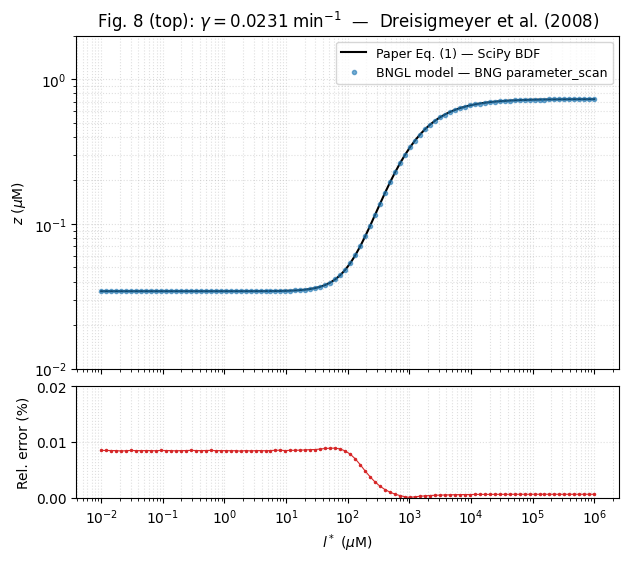

Saved verify_dreisigmeyer2008.png


In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), height_ratios=[3, 1],
                               sharex=True, gridspec_kw={"hspace": 0.08})

# --- Top panel: induction curves ---
ax1.loglog(bng_lx, paper_Z, "k-", lw=1.5, label="Paper Eq. (1) — SciPy BDF")
ax1.loglog(bng_lx, bng_Z, "o", color="tab:blue", ms=3, alpha=0.6,
           label="BNGL model — BNG parameter_scan")
ax1.set_ylabel(r"$z$ ($\mu$M)")
ax1.set_ylim(1e-2, 2)
ax1.legend(fontsize=9)
ax1.set_title(r"Fig. 8 (top): $\gamma = 0.0231\;\mathrm{min}^{-1}$"
              "  —  Dreisigmeyer et al. (2008)")
ax1.grid(True, which="both", ls=":", alpha=0.4)

# --- Bottom panel: relative error ---
rel_err = np.abs(bng_Z - paper_Z) / np.clip(paper_Z, 1e-15, None) * 100
ax2.semilogx(bng_lx, rel_err, ".-", color="tab:red", ms=3, lw=0.8)
ax2.set_ylabel("Rel. error (%)")
ax2.set_xlabel(r"$l^*$ ($\mu$M)")
ax2.set_ylim(0, max(0.02, rel_err.max() * 1.2))
ax2.grid(True, which="both", ls=":", alpha=0.4)

fig.tight_layout()
plt.savefig("verify_dreisigmeyer2008.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved verify_dreisigmeyer2008.png")